<a href="https://colab.research.google.com/github/branka2004/preporuka_proizvoda_u_elektronskoj_trgovini/blob/main/preporuka_proizvoda_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Primena deep learninga za preporuku proizvoda u elektronskoj trgovini pomoću autoenkodera

## Projekat iz predmeta: Duboko učenje i neuronske mreže

### Autori:
- Nikola Ilic 2022/0190
- Branka Bakovic 2022/0295

# Opis projekta

Cilj ovog projekta je implementacija sistema za preporuku proizvoda korišćenjem tehnika dubokog učenja i autoenkodera.

Model će biti treniran nad Amazon Reviews skupom podataka kako bi naučio latentne reprezentacije korisničkih preferencija i generisao personalizovane preporuke proizvoda.

U okviru projekta biće analizirane različite arhitekture autoenkodera, performanse modela i kvalitet preporuka korišćenjem standardnih evaluacionih metrika.

# Neophodni importi

In [18]:
import io
import os
import random

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

RAND_STATE = 42

print("PyTorch verzija:", torch.__version__)
print("Da li je GPU dostupan:", torch.cuda.is_available())

PyTorch verzija: 2.11.0+cu128
Da li je GPU dostupan: True


In [19]:
df = pd.read_csv('/content/Reviews.csv')

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


# Analiza skupa podataka

In [21]:
print("Broj redova i kolona:")
print(df.shape)

print("\nNazivi kolona:")
print(df.columns)

print("\nBroj jedinstvenih korisnika:")
print(df['UserId'].nunique())

print("\nBroj jedinstvenih proizvoda:")
print(df['ProductId'].nunique())

print("Nedostajuće vrednosti:\n")
print(df.isnull().sum())



Broj redova i kolona:
(568454, 10)

Nazivi kolona:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Broj jedinstvenih korisnika:
256059

Broj jedinstvenih proizvoda:
74258
Nedostajuće vrednosti:

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


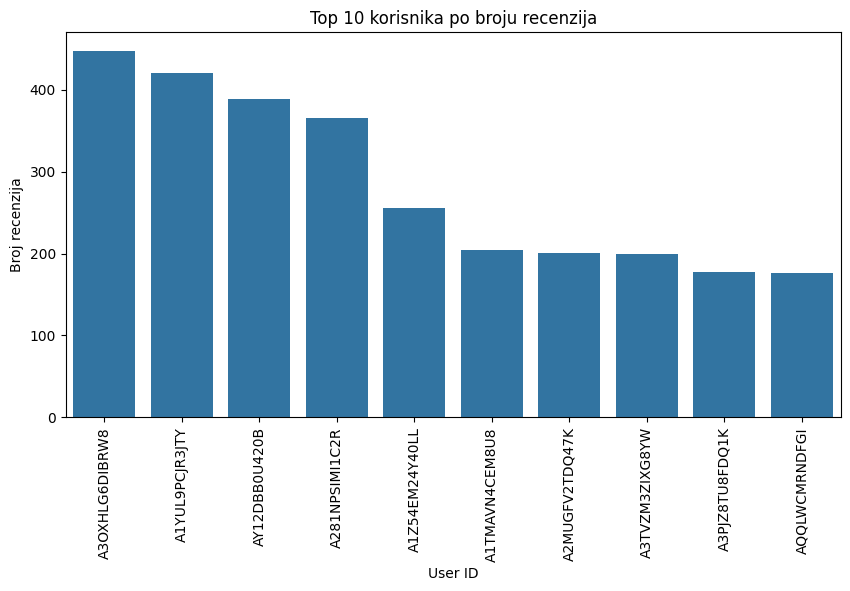

In [22]:
top_users = df['UserId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_users.index, y=top_users.values)

plt.title("Top 10 korisnika po broju recenzija")
plt.xlabel("User ID")
plt.ylabel("Broj recenzija")

plt.xticks(rotation=90)

plt.show()

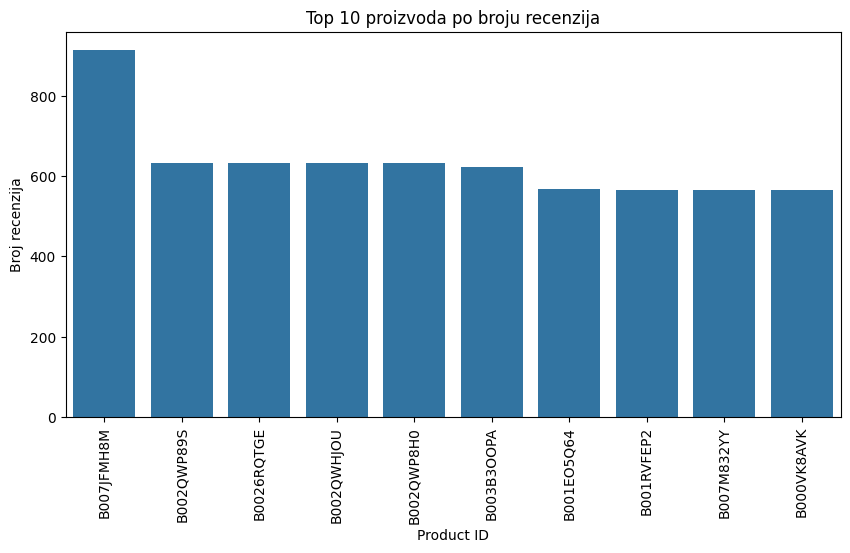

In [23]:
top_products = df['ProductId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top 10 proizvoda po broju recenzija")
plt.xlabel("Product ID")
plt.ylabel("Broj recenzija")

plt.xticks(rotation=90)

plt.show()

Na osnovu inicijalne analize skupa podataka može se uočiti da dataset sadrži veliki broj korisničkih recenzija i ocena proizvoda iz elektronske trgovine.

Skup podataka sadrži informacije o korisnicima, proizvodima, numeričkim ocenama, tekstualnim komentarima i vremenu ostavljanja recenzije.


# Preprocesiranje podataka

U sistemima za preporuku proizvoda, podaci se najčešće transformišu u tzv. user-item matricu.

Redovi matrice predstavljaju korisnike, kolone proizvode, dok vrednosti unutar matrice predstavljaju ocene koje su korisnici dodelili proizvodima.

S obzirom na veličinu originalnog skupa podataka i veliku sparsnost matrice, biće izvršena filtracija korisnika i proizvoda sa veoma malim brojem interakcija kako bi se omogućilo efikasnije treniranje modela.

In [24]:
# Broj recenzija po korisniku
user_counts = df['UserId'].value_counts()

# Broj recenzija po proizvodu
product_counts = df['ProductId'].value_counts()

In [25]:
# Zadržavamo samo korisnike sa minimum 20 recenzija
active_users = user_counts[user_counts >= 20].index

# Zadržavamo samo proizvode sa minimum 20 recenzija
popular_products = product_counts[product_counts >= 20].index

# Filtriran dataset
filtered_df = df[
    (df['UserId'].isin(active_users)) &
    (df['ProductId'].isin(popular_products))
]

print("Originalna dimenzija:", df.shape)
print("Filtrirana dimenzija:", filtered_df.shape)

Originalna dimenzija: (568454, 10)
Filtrirana dimenzija: (47380, 10)


Nakon inicijalne analize skupa podataka izvršena je filtracija korisnika i proizvoda sa veoma malim brojem interakcija.

U recommendation sistemima veliki broj korisnika ostavlja veoma mali broj recenzija, dok pojedini proizvodi imaju svega nekoliko ocena. Takvi podaci otežavaju proces učenja modela i mogu negativno uticati na kvalitet preporuka.

Iz tog razloga zadržani su samo korisnici koji imaju najmanje 20 recenzija, kao i proizvodi sa najmanje 20 ocena. Ovim postupkom smanjena je dimenzionalnost problema i povećan kvalitet podataka koji se koriste za treniranje modela.

Nakon filtracije broj interakcija značajno je smanjen, čime je omogućeno efikasnije treniranje neuronske mreže i stabilnija konstrukcija user-item matrice.


# Kreiranje user-item matrice

Nakon filtracije podataka, kreira se user-item matrica koja predstavlja osnovu sistema za preporuku proizvoda.

Svaki red matrice predstavlja jednog korisnika, dok svaka kolona predstavlja jedan proizvod. Vrednosti u matrici predstavljaju ocene koje su korisnici dodelili proizvodima.

Nedostajuće vrednosti biće popunjene nulama, što označava da korisnik nije ocenio određeni proizvod.

In [26]:
# Kreiranje user-item matrice

user_item_matrix = filtered_df.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Score'
)

# Popunjavanje nedostajućih vrednosti nulama
user_item_matrix = user_item_matrix.fillna(0)

print("Dimenzije user-item matrice:")
print(user_item_matrix.shape)

user_item_matrix.head()

Dimenzije user-item matrice:
(1879, 4308)


ProductId,7310172001,7310172101,B00004CI84,B00004CXX9,B00004RAMY,B00004RBDU,B00004RBDZ,B00004RYGX,B00004S1C6,B000084DWM,...,B009AFJ3I6,B009AFJ548,B009B87SAC,B009E7YC54,B009GHI5Q4,B009HXB2JO,B009M2LPHO,B009M2LRTA,B009M2LUEW,B009RB4GO4
UserId,,,,,,,,,,,,,,,,,,,,,
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A101P2KHWCU0G6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
A1051DBTLWP5A2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A106ZCP7RSXMRU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1080SE9X3ECK0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


User-item matrica predstavlja centralnu komponentu sistema za preporuku proizvoda.

Redovi matrice predstavljaju korisnike, kolone predstavljaju proizvode, dok vrednosti unutar matrice predstavljaju ocene koje su korisnici dodelili proizvodima.

U slučajevima kada korisnik nije ocenio određeni proizvod, vrednost se popunjava nulom. Ovakva reprezentacija omogućava neuronskoj mreži da analizira obrasce korisničkih preferencija i pronalazi skrivene relacije između proizvoda i korisnika.

Dobijena matrica predstavlja ulaz u autoencoder model koji će pokušati da rekonstruiše korisničke preference i predvidi potencijalno interesantne proizvode za svakog korisnika.


In [27]:
# Sparsity matrice

matrix_values = user_item_matrix.values

sparsity = 1.0 - (
    np.count_nonzero(matrix_values) /
    float(matrix_values.size)
)

print(f"Sparsity matrice: {sparsity:.4f}")

Sparsity matrice: 0.9947


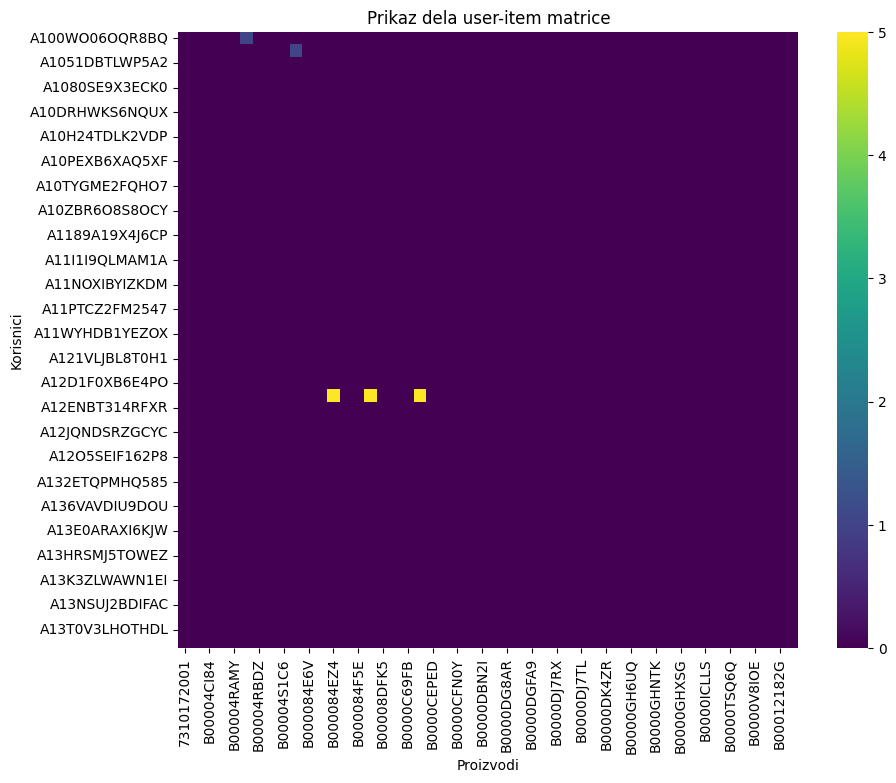

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    user_item_matrix.iloc[:50, :50],
    cmap='viridis'
)

plt.title("Prikaz dela user-item matrice")

plt.xlabel("Proizvodi")
plt.ylabel("Korisnici")

plt.show()

Analiza sparsnosti user-item matrice pokazuje da veliki broj elemenata matrice sadrži nulte vrednosti, odnosno nedostajuće interakcije između korisnika i proizvoda.

Dobijena vrednost sparsnosti od približno 99% ukazuje da većina korisnika ocenjuje samo mali broj proizvoda, što predstavlja tipičan problem recommendation sistema u realnim uslovima.

Visoka sparsnost otežava proces predviđanja korisničkih preferencija jer model raspolaže ograničenim brojem poznatih interakcija. Upravo zbog toga autoenkoderi predstavljaju pogodno rešenje, budući da mogu naučiti latentne reprezentacije korisnika i proizvoda čak i u uslovima veoma retkih podataka.

Na osnovu kreirane user-item matrice može se uočiti izražena sparsnost podataka, što predstavlja tipičan problem u sistemima za preporuku proizvoda.

Veliki broj nedostajućih interakcija između korisnika i proizvoda otežava proces učenja modela, zbog čega su autoenkoderi pogodni za pronalaženje latentnih reprezentacija i rekonstrukciju korisničkih preferencija.

# Priprema podataka za treniranje modela

In [29]:
# Konverzija user-item matrice u NumPy niz

matrix = user_item_matrix.values

print("Dimenzije matrice:")
print(matrix.shape)

Dimenzije matrice:
(1879, 4308)


In [30]:
# Podela na trening i test skup

X_train, X_test = train_test_split(
    matrix,
    test_size=0.2,
    random_state=RAND_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1503, 4308)
Test shape: (376, 4308)


In [31]:
# Skaliranje podataka

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Minimalna vrednost:", X_train_scaled.min())
print("Maksimalna vrednost:", X_train_scaled.max())

Minimalna vrednost: 0.0
Maksimalna vrednost: 1.0


In [32]:
# Konverzija u PyTorch tenzore

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

print("Shape trening tenzora:", X_train_tensor.shape)
print("Shape test tenzora:", X_test_tensor.shape)

Shape trening tenzora: torch.Size([1503, 4308])
Shape test tenzora: torch.Size([376, 4308])


U dubokom učenju podaci se veoma retko obrađuju odjednom u celosti, naročito kada dataset sadrži veliki broj korisnika i proizvoda. Iz tog razloga koristi se tehnika mini-batch treniranja.

Mini-batch predstavlja manju grupu uzoraka koja se prosleđuje neuronskoj mreži tokom jednog prolaza kroz model. U ovom projektu korišćen je batch size od 64, što znači da model tokom jedne iteracije obrađuje 64 korisnika iz user-item matrice.

Korišćenje mini-batcheva donosi više značajnih prednosti:

* značajno smanjuje potrošnju memorije,
* ubrzava treniranje modela,
* omogućava stabilnije računanje gradijenata,
* poboljšava generalizaciju modela,
* omogućava efikasno korišćenje GPU akceleracije.

DataLoader objekti dodatno omogućavaju automatsko mešanje trening podataka (shuffle=True), čime se sprečava da neuronska mreža nauči redosled podataka umesto stvarnih obrazaca korisničkih preferencija.


In [33]:
# Kreiranje DataLoader-a

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoader uspešno kreiran.")

DataLoader uspešno kreiran.


Pre treniranja neuronske mreže bilo je neophodno izvršiti dodatnu pripremu i transformaciju podataka u format pogodan za rad sa PyTorch bibliotekom i modelima dubokog učenja.

Kreirana user-item matrica predstavlja osnovnu reprezentaciju korisničkih interakcija sa proizvodima. Svaki red matrice predstavlja jednog korisnika, dok svaka kolona predstavlja određeni proizvod. Vrednosti unutar matrice odgovaraju ocenama koje su korisnici dodelili proizvodima.

Kako neuronske mreže rade nad numeričkim matricama fiksnih dimenzija, user-item matrica je najpre konvertovana u NumPy niz, nakon čega je izvršena podela podataka na trening i test skup. Ova podela omogućava procenu sposobnosti modela da generalizuje korisničke preference i generiše preporuke za neviđene podatke.

Nakon podele podataka izvršena je normalizacija korišćenjem MinMaxScaler metode. Normalizacija predstavlja važan korak u dubokom učenju jer omogućava stabilnije treniranje modela, bržu konvergenciju funkcije greške i efikasnije računanje gradijenata tokom procesa optimizacije. Sve vrednosti matrice transformisane su u opseg između 0 i 1.

Transformisani podaci zatim su konvertovani u PyTorch tenzore. Tenzori predstavljaju osnovnu strukturu podataka u PyTorch okruženju i optimizovani su za izvođenje matematičkih operacija nad velikim matricama, kao i za korišćenje GPU akceleracije tokom treniranja modela.

Na kraju su podaci organizovani pomoću DataLoader objekata koji omogućavaju efikasno učitavanje podataka u manjim grupama (mini-batchevima) tokom treniranja neuronske mreže.

# Model 1: Baseline Autoencoder

Autoencoder predstavlja specijalizovanu arhitekturu neuronskih mreža namenjenu učenju latentnih reprezentacija podataka i rekonstrukciji ulaznih vrednosti.

Za razliku od klasičnih neuronskih mreža koje vrše klasifikaciju ili regresiju, cilj autoenkodera nije direktno predviđanje klase, već rekonstrukcija originalnog ulaza kroz proces kompresije i dekompresije informacija.

Model se sastoji iz dva osnovna dela:

* Encoder dela, čiji je zadatak da kompresuje ulazne podatke i pronađe skrivene obrasce u korisničkim preferencijama.
* Decoder dela, koji iz latentne reprezentacije pokušava da rekonstruiše originalnu user-item matricu.

Centralni deo autoenkodera predstavlja latentni prostor (latent space), odnosno kompresovana reprezentacija korisničkih preferencija. U ovom prostoru model pokušava da nauči skrivene relacije između korisnika i proizvoda, kao i obrasce ponašanja koji nisu direktno vidljivi u originalnim podacima.

U recommendation sistemima autoenkoderi su posebno pogodni za rad sa veoma sparse matricama, budući da mogu da predviđaju nedostajuće interakcije između korisnika i proizvoda na osnovu prethodno naučenih obrazaca.


In [34]:
# Definicija baseline autoencoder modela

class Autoencoder(nn.Module):

    def __init__(self, input_dim):

        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 512),
            nn.ReLU(),

            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [35]:
# Kreiranje modela

input_dim = X_train_tensor.shape[1]

model_1_autoencoder = Autoencoder(input_dim)

print(model_1_autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4308, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=4308, bias=True)
    (5): Sigmoid()
  )
)


Arhitektura baseline autoenkodera sastoji se iz više potpuno povezanih slojeva (fully connected layers) organizovanih kroz encoder i decoder deo mreže.

Ulazni sloj mreže sadrži 4308 neurona, što odgovara broju proizvoda u user-item matrici nakon izvršene filtracije podataka. Svaki neuron na ulazu predstavlja jednu dimenziju korisničkih preferencija, odnosno ocenu određenog proizvoda.

Encoder deo mreže postepeno smanjuje dimenzionalnost ulaznih podataka:

* prvi skriveni sloj kompresuje podatke na 512 neurona,
* zatim se informacije dodatno redukuju na 128 neurona,
* nakon čega se formira latentna reprezentacija dimenzije 64.

Proces postepene kompresije omogućava modelu da izdvoji najvažnije obrasce korisničkih preferencija i ukloni redundantne informacije iz originalne user-item matrice.

Centralni deo mreže predstavlja latentni prostor (latent space), u kome model pokušava da nauči skrivene relacije između korisnika i proizvoda, kao i latentne obrasce ponašanja koji nisu direktno vidljivi u originalnim podacima.

Decoder deo mreže vrši obrnut proces rekonstrukcije — latentna reprezentacija se postepeno proširuje kroz više slojeva kako bi se rekonstruisala originalna user-item matrica i predvidele potencijalno nedostajuće ocene proizvoda.

Kao aktivaciona funkcija korišćena je ReLU funkcija zbog svoje efikasnosti i stabilnosti u dubokim neuronskim mrežama, dok je na izlaznom sloju korišćena Sigmoid funkcija kako bi izlazne vrednosti bile ograničene na interval između 0 i 1.


# Trening baseline autoenkodera

Nakon definisanja arhitekture neuronske mreže, sledeći korak predstavlja proces treniranja autoenkodera.

Cilj treniranja autoenkodera nije klasifikacija podataka, već rekonstrukcija originalne user-item matrice. Model pokušava da iz kompresovane latentne reprezentacije rekonstruiše korisničke preference i što preciznije reprodukuje originalne ocene proizvoda.

Tokom procesa treniranja neuronska mreža prolazi kroz više epoha. Jedna epoha predstavlja jedan kompletan prolaz kroz ceo trening skup podataka.

U svakoj iteraciji model:

* prima ulazne podatke,
* generiše rekonstrukciju user-item matrice,
* računa grešku rekonstrukcije,
* propagira grešku unazad kroz mrežu (backpropagation),
* ažurira težinske koeficijente koristeći optimizacioni algoritam.

Za optimizaciju modela korišćen je Adam optimizer sa stopom učenja od 0.001, dok je kao funkcija greške korišćena srednja kvadratna greška (MSE Loss).

MSE Loss meri prosečno odstupanje između originalnih i rekonstruisanih vrednosti user-item matrice i predstavlja standardnu funkciju greške za rekonstrukcione modele poput autoenkodera.


In [36]:
# Definisanje funkcije greške i optimizatora

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model_1_autoencoder.parameters(),
    lr=0.001
)

print("Funkcija greške i optimizer uspešno definisani.")

Funkcija greške i optimizer uspešno definisani.


In [37]:
# Trening baseline autoenkodera

EPOCHS = 20

loss_history = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1_autoencoder = model_1_autoencoder.to(device)

print("Korišćeni uređaj:", device)

for epoch in range(EPOCHS):

    model_1_autoencoder.train()

    epoch_loss = 0.0

    for batch in train_loader:

        # Uzimamo batch podataka
        inputs = batch[0].to(device)

        # Resetovanje gradijenata
        optimizer.zero_grad()

        # Forward pass
        outputs = model_1_autoencoder(inputs)

        # Računanje greške rekonstrukcije
        loss = criterion(outputs, inputs)

        # Backpropagation
        loss.backward()

        # Ažuriranje težina
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    loss_history.append(average_loss)

    print(f"Epoha [{epoch+1}/{EPOCHS}] | Loss: {average_loss:.6f}")

Korišćeni uređaj: cuda
Epoha [1/20] | Loss: 0.123467
Epoha [2/20] | Loss: 0.003955
Epoha [3/20] | Loss: 0.003952
Epoha [4/20] | Loss: 0.003946
Epoha [5/20] | Loss: 0.003964
Epoha [6/20] | Loss: 0.003937
Epoha [7/20] | Loss: 0.003952
Epoha [8/20] | Loss: 0.003962
Epoha [9/20] | Loss: 0.003963
Epoha [10/20] | Loss: 0.003944
Epoha [11/20] | Loss: 0.003950
Epoha [12/20] | Loss: 0.003947
Epoha [13/20] | Loss: 0.003954
Epoha [14/20] | Loss: 0.003961
Epoha [15/20] | Loss: 0.003967
Epoha [16/20] | Loss: 0.003950
Epoha [17/20] | Loss: 0.003948
Epoha [18/20] | Loss: 0.003963
Epoha [19/20] | Loss: 0.003946
Epoha [20/20] | Loss: 0.003940


Proces treniranja autoenkodera odvijao se kroz 20 epoha korišćenjem mini-batch pristupa.

Tokom svake epohe model je prolazio kroz trening podatke i pokušavao da minimizuje grešku rekonstrukcije između originalne i rekonstruisane user-item matrice.

U svakoj iteraciji izvršavani su sledeći koraci:

* prolaz unapred kroz mrežu (forward pass),
* računanje greške rekonstrukcije,
* propagacija greške unazad kroz mrežu (backpropagation),
* ažuriranje težinskih koeficijenata pomoću Adam optimizatora.

Kao funkcija greške korišćena je srednja kvadratna greška (Mean Squared Error – MSE), koja meri prosečno odstupanje između stvarnih i rekonstruisanih vrednosti matrice.

Tokom treniranja model je izvršavan na GPU uređaju korišćenjem CUDA akceleracije, čime je omogućeno značajno brže izvođenje matematičkih operacija nad velikim matricama podataka.


# Promena vrednosti funkcije greške tokom treninga

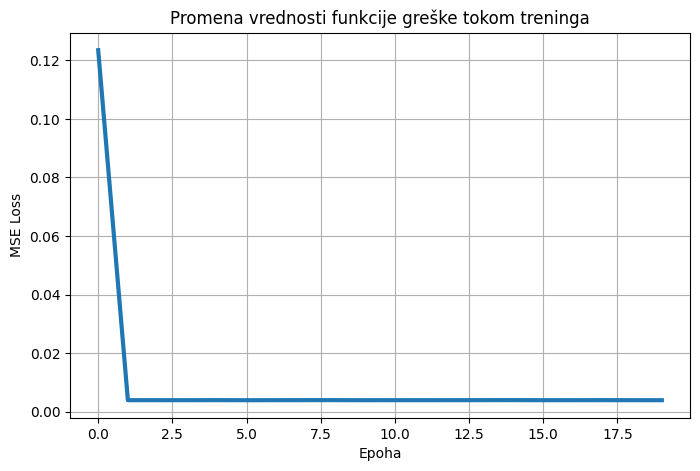

In [38]:
# Vizualizacija loss funkcije
plt.figure(figsize=(8,5))

plt.plot(loss_history, linewidth=3)

plt.title("Promena vrednosti funkcije greške tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

Na osnovu prikazanog grafikona može se uočiti veoma brz pad vrednosti funkcije greške tokom prvih epoha treniranja, nakon čega dolazi do stabilizacije modela.

Ovakvo ponašanje ukazuje da je autoencoder veoma brzo uspeo da nauči osnovne obrasce korisničkih preferencija i rekonstruiše najveći deo informacija iz user-item matrice.

Nakon početnog procesa učenja vrednost funkcije greške ostaje stabilna, što predstavlja indikator konvergencije modela i stabilnog procesa optimizacije bez značajnih oscilacija.

Brza konvergencija modela može se objasniti prethodnom filtracijom podataka, normalizacijom vrednosti i relativno jednostavnom arhitekturom autoenkodera koja omogućava efikasno učenje latentnih reprezentacija korisnika i proizvoda.

Dobijeni rezultati potvrđuju da model uspešno uči kompresovane reprezentacije korisničkih preferencija i postiže stabilnu rekonstrukciju user-item matrice.


# Evaluacija performansi modela

Nakon procesa treniranja izvršena je evaluacija performansi autoencoder modela nad test skupom podataka.

Cilj evaluacije bio je da se ispita koliko uspešno model rekonstruiše korisničke preference i predviđa vrednosti user-item matrice na podacima koji nisu korišćeni tokom treniranja.

Za procenu kvaliteta modela korišćene su standardne metrike za rekonstrukcione i recommendation modele:

* RMSE (Root Mean Squared Error)
* MAE (Mean Absolute Error)

RMSE predstavlja kvadratni koren srednje kvadratne greške i meri prosečno odstupanje između stvarnih i predviđenih vrednosti. Ova metrika dodatno kažnjava velika odstupanja između rekonstrukcije i originalnih podataka.

MAE predstavlja prosečnu apsolutnu grešku između stvarnih i rekonstruisanih vrednosti i pruža intuitivnu procenu prosečne greške modela.

Niže vrednosti RMSE i MAE ukazuju na kvalitetniju rekonstrukciju korisničkih preferencija i bolje performanse recommendation sistema.


In [39]:
# Evaluacija modela na test skupu

model_1_autoencoder.eval()

with torch.no_grad():

    reconstructed = model_1_autoencoder(
        X_test_tensor.to(device)
    )

# Prebacivanje na CPU i NumPy format
reconstructed = reconstructed.cpu().numpy()

# Originalne vrednosti
original = X_test_tensor.cpu().numpy()

print("Evaluacija završena.")

Evaluacija završena.


In [40]:
# Računanje RMSE i MAE metrika

rmse = np.sqrt(
    mean_squared_error(
        original.flatten(),
        reconstructed.flatten()
    )
)

mae = mean_absolute_error(
    original.flatten(),
    reconstructed.flatten()
)

print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")

RMSE: 0.080830
MAE: 0.004911


# Poređenje originalnih i rekonstruisanih vrednosti

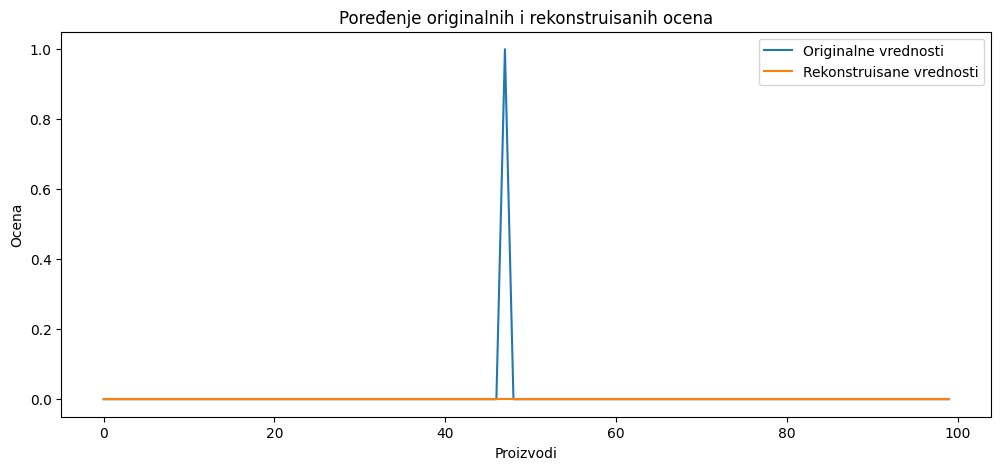

In [41]:
# Prikaz dela originalnih i rekonstruisanih vrednosti

sample_user = 0

plt.figure(figsize=(12,5))

# Originalne vrednosti
plt.plot(
    original[sample_user][:100],
    label='Originalne vrednosti'
)

# Rekonstruisane vrednosti
plt.plot(
    reconstructed[sample_user][:100],
    label='Rekonstruisane vrednosti'
)

plt.title("Poređenje originalnih i rekonstruisanih ocena")
plt.xlabel("Proizvodi")
plt.ylabel("Ocena")

plt.legend()

plt.show()

In [42]:
# Prikaz proizvoda koje je korisnik ocenio

sample_user = 0

# Indeksi gde postoje ocene
rated_indices = np.where(original[sample_user] > 0)[0]

comparison_df = pd.DataFrame({
    "Original": original[sample_user][rated_indices][:20],
    "Reconstructed": reconstructed[sample_user][rated_indices][:20]
})

comparison_df

comparison_df

,Original,Reconstructed
0,1.0,7.033948e-38
1,1.0,1.274282e-36
2,0.6,2.930524e-35
3,0.6,3.884002e-35
4,0.8,2.784656e-37
5,0.8,1.848154e-34
6,1.0,3.125421e-36
7,5.0,1.088999e-37
8,1.0,7.524724e-34
9,1.0,2.010081e-35


Analiza rekonstruisanih vrednosti pokazuje da baseline autoencoder u velikoj meri teži predviđanju veoma malih vrednosti za većinu proizvoda.

Ovakvo ponašanje predstavlja čestu pojavu kod recommendation sistema zasnovanih na veoma sparse user-item matricama. S obzirom na to da najveći deo matrice sadrži nulte vrednosti, model tokom optimizacije pokušava da minimizuje ukupnu grešku rekonstrukcije favorizovanjem veoma malih izlaznih vrednosti.

Iako model uspešno postiže relativno nisku vrednost funkcije greške, može se primetiti da rekonstruisane vrednosti ne prate dovoljno precizno originalne ocene korisnika za proizvode koje su zaista ocenili.

Ovakvi rezultati ukazuju na potrebu za dodatnom optimizacijom arhitekture autoenkodera i podešavanjem hiperparametara modela kako bi se poboljšala sposobnost rekonstrukcije korisničkih preferencija.

U nastavku projekta biće implementirana unapređena arhitektura autoenkodera sa ciljem poboljšanja performansi recommendation sistema.


# Model 2: Unapređeni autoenkoder

Nakon analize performansi baseline autoenkodera uočeno je da model teži rekonstrukciji veoma malih vrednosti za najveći deo user-item matrice, što predstavlja čest problem kod recommendation sistema sa izrazito sparse podacima.

Iz tog razloga implementirana je unapređena arhitektura autoenkodera sa ciljem poboljšanja sposobnosti modela da rekonstruiše korisničke preference i predviđa nedostajuće interakcije između korisnika i proizvoda.

U unapređenom modelu izvršene su sledeće izmene:

* povećana je dimenzionalnost latentnog prostora,
* dodati su Dropout slojevi radi smanjenja overfitting-a,
* uvedena je Batch Normalization tehnika radi stabilnijeg treniranja,
* uklonjena je Sigmoid aktivaciona funkcija sa izlaznog sloja,
* povećan je broj epoha treniranja.

Cilj ovih modifikacija jeste poboljšanje generalizacije modela i preciznija rekonstrukcija korisničkih ocena proizvoda.


In [43]:
# Definicija unapređenog autoenkodera

class ImprovedAutoencoder(nn.Module):

    def __init__(self, input_dim):

        super(ImprovedAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 1024),
            nn.ReLU(),

            nn.Linear(1024, input_dim)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [44]:
# Kreiranje unapređenog modela

model_2_autoencoder = ImprovedAutoencoder(input_dim)

model_2_autoencoder = model_2_autoencoder.to(device)

print(model_2_autoencoder)

ImprovedAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4308, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=4308, bias=True)
  )
)


Unapređena arhitektura autoenkodera koristi dublju neuronsku mrežu i veći broj neurona u latentnom prostoru u odnosu na baseline model.

Povećanjem dimenzionalnosti latentnog prostora omogućeno je modelu da nauči složenije obrasce korisničkih preferencija i relacije između proizvoda.

U model su dodatno uključeni Dropout slojevi koji nasumično deaktiviraju deo neurona tokom treniranja, čime se smanjuje rizik od overfitting-a i poboljšava generalizacija modela.

Batch Normalization slojevi korišćeni su radi stabilizacije distribucije aktivacija tokom treniranja, što omogućava bržu i stabilniju konvergenciju neuronske mreže.

Za razliku od baseline modela, sa izlaznog sloja uklonjena je Sigmoid funkcija kako bi model imao veću fleksibilnost pri rekonstrukciji korisničkih ocena i kako bi se smanjila tendencija predviđanja veoma malih vrednosti.


# Trening unapređenog autoenkodera

In [45]:
# Funkcija greške i optimizer

criterion_2 = nn.MSELoss()

optimizer_2 = optim.Adam(
    model_2_autoencoder.parameters(),
    lr=0.0005
)

In [46]:
# Trening unapređenog autoenkodera

EPOCHS_2 = 30

loss_history_2 = []

for epoch in range(EPOCHS_2):

    model_2_autoencoder.train()

    epoch_loss = 0.0

    for batch in train_loader:

        inputs = batch[0].to(device)

        optimizer_2.zero_grad()

        outputs = model_2_autoencoder(inputs)

        loss = criterion_2(outputs, inputs)

        loss.backward()

        optimizer_2.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    loss_history_2.append(average_loss)

    print(f"Epoha [{epoch+1}/{EPOCHS_2}] | Loss: {average_loss:.6f}")

Epoha [1/30] | Loss: 0.004025
Epoha [2/30] | Loss: 0.003519
Epoha [3/30] | Loss: 0.003281
Epoha [4/30] | Loss: 0.003091
Epoha [5/30] | Loss: 0.002935
Epoha [6/30] | Loss: 0.002786
Epoha [7/30] | Loss: 0.002696
Epoha [8/30] | Loss: 0.002628
Epoha [9/30] | Loss: 0.002531
Epoha [10/30] | Loss: 0.002489
Epoha [11/30] | Loss: 0.002405
Epoha [12/30] | Loss: 0.002347
Epoha [13/30] | Loss: 0.002295
Epoha [14/30] | Loss: 0.002258
Epoha [15/30] | Loss: 0.002198
Epoha [16/30] | Loss: 0.002154
Epoha [17/30] | Loss: 0.002110
Epoha [18/30] | Loss: 0.002065
Epoha [19/30] | Loss: 0.002039
Epoha [20/30] | Loss: 0.001988
Epoha [21/30] | Loss: 0.001960
Epoha [22/30] | Loss: 0.001911
Epoha [23/30] | Loss: 0.001868
Epoha [24/30] | Loss: 0.001851
Epoha [25/30] | Loss: 0.001814
Epoha [26/30] | Loss: 0.001795
Epoha [27/30] | Loss: 0.001745
Epoha [28/30] | Loss: 0.001715
Epoha [29/30] | Loss: 0.001688
Epoha [30/30] | Loss: 0.001663


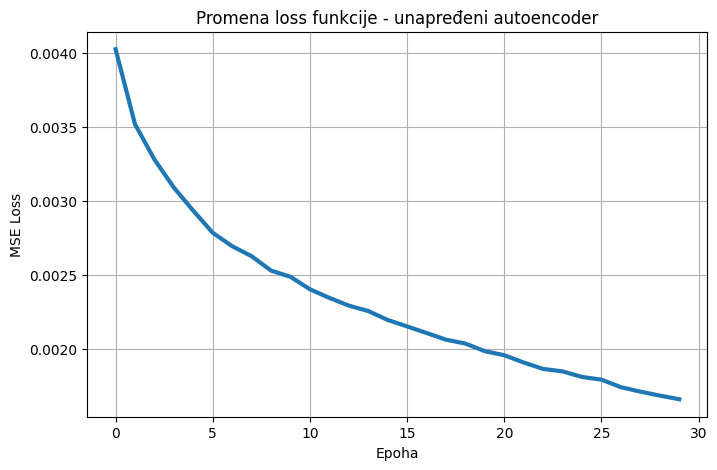

In [47]:
# Grafik loss funkcije unapređenog modela

plt.figure(figsize=(8,5))

plt.plot(loss_history_2, linewidth=3)

plt.title("Promena loss funkcije - unapređeni autoencoder")
plt.xlabel("Epoha")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

Na osnovu prikazanog grafikona može se uočiti postepeno i stabilno opadanje vrednosti funkcije greške tokom procesa treniranja unapređenog autoenkodera.

Za razliku od baseline modela, unapređeni autoencoder pokazuje znatno stabilnije ponašanje tokom optimizacije i kontinuirano poboljšavanje rekonstrukcije user-item matrice kroz veći broj epoha.

Postepeni pad MSE Loss funkcije ukazuje da model uspešno uči latentne reprezentacije korisničkih preferencija i pronalazi obrasce interakcije između korisnika i proizvoda.

Dodavanje Batch Normalization i Dropout slojeva doprinelo je stabilnijem procesu treniranja i boljoj generalizaciji modela, dok je povećana dimenzionalnost latentnog prostora omogućila efikasnije modelovanje kompleksnih relacija unutar sparse user-item matrice.

Stabilna konvergencija bez izraženih oscilacija predstavlja indikator pravilno podešenog procesa optimizacije i uspešnog treniranja neuronske mreže.


# Evaluacija unapređenog autoenkodera

Nakon treniranja unapređenog autoenkodera izvršena je evaluacija modela nad test skupom podataka kako bi se procenio kvalitet rekonstrukcije korisničkih preferencija.

Cilj evaluacije bio je da se ispita da li unapređena arhitektura postiže bolje performanse u odnosu na baseline model i da li uspešnije rekonstruiše interakcije između korisnika i proizvoda.

Kao i kod prethodnog modela, korišćene su RMSE i MAE metrike koje predstavljaju standardne mere uspešnosti recommendation sistema i rekonstrukcionih modela.


In [48]:
# Evaluacija unapređenog autoenkodera

model_2_autoencoder.eval()

with torch.no_grad():

    reconstructed_2 = model_2_autoencoder(
        X_test_tensor.to(device)
    )

# Prebacivanje na CPU
reconstructed_2 = reconstructed_2.cpu().numpy()

# Originalne vrednosti
original_2 = X_test_tensor.cpu().numpy()

print("Evaluacija modela 2 završena.")

Evaluacija modela 2 završena.


In [49]:
# Računanje RMSE i MAE za model 2

rmse_2 = np.sqrt(
    mean_squared_error(
        original_2.flatten(),
        reconstructed_2.flatten()
    )
)

mae_2 = mean_absolute_error(
    original_2.flatten(),
    reconstructed_2.flatten()
)

print(f"RMSE model 2: {rmse_2:.6f}")
print(f"MAE model 2: {mae_2:.6f}")

RMSE model 2: 0.069230
MAE model 2: 0.010452


In [50]:
# Poređenje originalnih i rekonstruisanih vrednosti

sample_user = 0

rated_indices = np.where(original_2[sample_user] > 0)[0]

comparison_df_2 = pd.DataFrame({
    "Original": original_2[sample_user][rated_indices][:20],
    "Reconstructed": reconstructed_2[sample_user][rated_indices][:20]
})

comparison_df_2

,Original,Reconstructed
0,1.0,0.000986
1,1.0,0.004448
2,0.6,0.079245
3,0.6,0.087105
4,0.8,0.076579
5,0.8,0.082445
6,1.0,0.199674
7,5.0,-0.001231
8,1.0,0.002939
9,1.0,0.305393


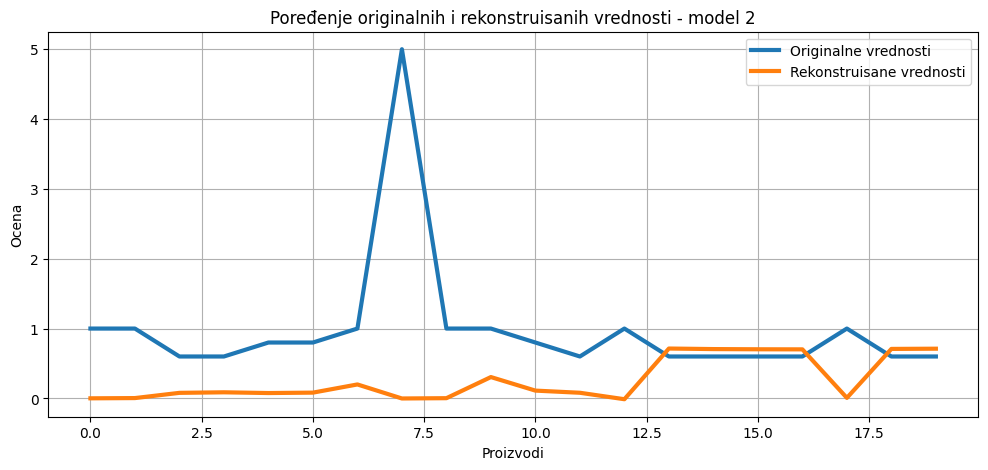

In [51]:
# Grafik poređenja rekonstrukcije

plt.figure(figsize=(12,5))

plt.plot(
    original_2[sample_user][rated_indices][:20],
    label='Originalne vrednosti',
    linewidth=3
)

plt.plot(
    reconstructed_2[sample_user][rated_indices][:20],
    label='Rekonstruisane vrednosti',
    linewidth=3
)

plt.title("Poređenje originalnih i rekonstruisanih vrednosti - model 2")
plt.xlabel("Proizvodi")
plt.ylabel("Ocena")

plt.legend()

plt.grid(True)

plt.show()

# Poređenje performansi modela

In [52]:
# Poređenje performansi modela

comparison_metrics = pd.DataFrame({

    "Model": [
        "Baseline Autoencoder",
        "Improved Autoencoder"
    ],

    "RMSE": [
        rmse,
        rmse_2
    ],

    "MAE": [
        mae,
        mae_2
    ]
})

comparison_metrics

,Model,RMSE,MAE
0,Baseline Autoencoder,0.08083,0.004911
1,Improved Autoencoder,0.06923,0.010452


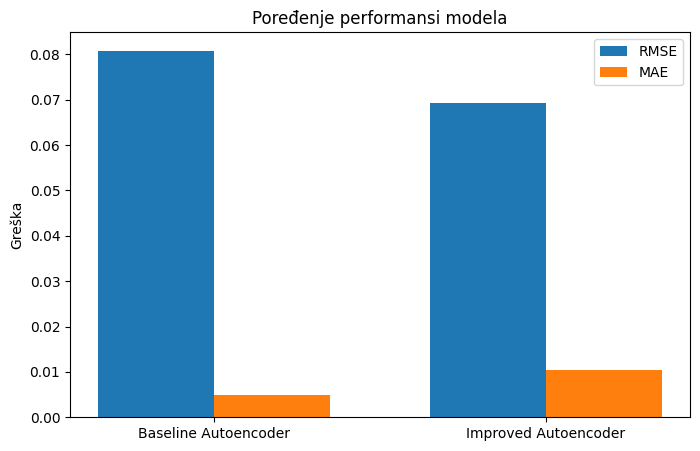

In [53]:
# Vizualizacija poređenja modela

x = np.arange(2)

width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    x - width/2,
    comparison_metrics["RMSE"],
    width,
    label='RMSE'
)

ax.bar(
    x + width/2,
    comparison_metrics["MAE"],
    width,
    label='MAE'
)

ax.set_xticks(x)
ax.set_xticklabels(comparison_metrics["Model"])

ax.set_title("Poređenje performansi modela")
ax.set_ylabel("Greška")

ax.legend()

plt.show()

Rezultati evaluacije pokazali su značajne razlike između baseline i unapređenog autoenkodera.

Baseline autoencoder ostvario je relativno nisku vrednost funkcije greške, ali analiza rekonstruisanih vrednosti pokazala je da model ima izraženu tendenciju predviđanja veoma malih vrednosti za većinu proizvoda. Ovakvo ponašanje predstavlja tipičan problem recommendation sistema zasnovanih na veoma sparse user-item matricama.

S obzirom na to da najveći deo matrice sadrži nulte vrednosti, baseline model tokom optimizacije favorizuje rekonstrukcije bliske nuli kako bi minimizovao ukupnu grešku rekonstrukcije.

Iz tog razloga implementirana je unapređena arhitektura autoenkodera koja koristi:

* dublju neuronsku mrežu,
* veći latentni prostor,
* Batch Normalization slojeve,
* Dropout regularizaciju,
* optimizovanu arhitekturu decoder dela.

Rezultati unapređenog modela pokazali su nižu RMSE vrednost i znatno raznovrsnije rekonstruisane ocene proizvoda, što ukazuje na uspešnije modelovanje latentnih korisničkih preferencija.

Na prikazanom grafikonu poređenja performansi modela može se uočiti da unapređeni autoencoder ostvaruje nižu RMSE vrednost u odnosu na baseline model, što ukazuje na kvalitetniju rekonstrukciju user-item matrice.

Poboljšanje performansi rezultat je dublje arhitekture neuronske mreže, povećane dimenzionalnosti latentnog prostora i primene regularizacionih tehnika poput Batch Normalization i Dropout slojeva.

Dobijeni rezultati potvrđuju da optimizacija arhitekture autoenkodera može značajno unaprediti kvalitet recommendation sistema i omogućiti uspešnije modelovanje korisničkih preferencija u uslovima veoma sparse podataka.

